In [58]:
%load_ext sql
import pandas as pd
import matplotlib as mlp
import sqlite3
%reload_ext sql
print("load_ext for sql")

The sql extension is already loaded. To reload it, use:
  %reload_ext sql
load_ext for sql


In [35]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [36]:
conn = sqlite3.connect("netflix.db")

df.to_sql(
    name="netflix_titles",
    con=conn,
    if_exists="replace",
    index=False
)

conn.close()


In [37]:
%sql sqlite:///netflix.db

In [40]:
import prettytable

In [41]:
prettytable.DEFAULT = 'DEFAULT'

In [42]:
%%sql
SELECT COUNT(*) AS total_rows
FROM netflix_titles;

   sqlite:///:memory:
 * sqlite:///netflix.db


,total_rows
0,8807


In [43]:
%%sql
-- Count total number of titles in the Netflix dataset
SELECT
    COUNT(*) AS total_titles
FROM netflix_titles;


   sqlite:///:memory:
 * sqlite:///netflix.db


,total_titles
0,8807


In [44]:
%%sql
-- Count how many Movies and TV Shows exist
-- GROUP BY categorizes by content type

SELECT
    type,
    COUNT(*) AS total_titles
FROM netflix_titles
GROUP BY type;


   sqlite:///:memory:
 * sqlite:///netflix.db


,type,total_titles
0,Movie,6131
1,TV Show,2676


In [45]:
%%sql
-- Count titles by maturity rating (e.g., TV-MA, PG-13)

SELECT
    rating,
    COUNT(*) AS total_titles
FROM netflix_titles
WHERE rating IS NOT NULL
GROUP BY rating
ORDER BY total_titles DESC;


   sqlite:///:memory:
 * sqlite:///netflix.db


,rating,total_titles
0,TV-MA,3207
1,TV-14,2160
2,TV-PG,863
3,R,799
4,PG-13,490
5,TV-Y7,334
6,TV-Y,307
7,PG,287
8,TV-G,220
9,NR,80


In [46]:
%%sql
-- Extract year from date_added and count titles per year
-- SUBSTR is used because date_added is stored as text

SELECT
    SUBSTR(date_added, -4) AS year_added,
    COUNT(*) AS total_titles
FROM netflix_titles
WHERE date_added IS NOT NULL
GROUP BY year_added
ORDER BY year_added;


   sqlite:///:memory:
 * sqlite:///netflix.db


,year_added,total_titles
0,2008,2
1,2009,2
2,2010,1
3,2011,13
4,2012,3
5,2013,11
6,2014,24
7,2015,82
8,2016,429
9,2017,1188


In [47]:
%%sql
-- Identify countries with the highest number of titles

SELECT
    country,
    COUNT(*) AS total_titles
FROM netflix_titles
WHERE country IS NOT NULL
GROUP BY country
ORDER BY total_titles DESC
LIMIT 10;


   sqlite:///:memory:
 * sqlite:///netflix.db


,country,total_titles
0,United States,2818
1,India,972
2,United Kingdom,419
3,Japan,245
4,South Korea,199
5,Canada,181
6,Spain,145
7,France,124
8,Mexico,110
9,Egypt,106


In [48]:
%%sql
-- Calculate average duration of movies
-- Remove ' min' text and cast to integer

SELECT
    ROUND(AVG(CAST(REPLACE(duration, ' min', '') AS INTEGER)), 1) AS avg_movie_minutes
FROM netflix_titles
WHERE type = 'Movie';


   sqlite:///:memory:
 * sqlite:///netflix.db


,avg_movie_minutes
0,99.6


In [49]:
%%sql
-- List the longest movies by duration

SELECT
    title,
    CAST(REPLACE(duration, ' min', '') AS INTEGER) AS minutes
FROM netflix_titles
WHERE type = 'Movie'
ORDER BY minutes DESC
LIMIT 10;


   sqlite:///:memory:
 * sqlite:///netflix.db


,title,minutes
0,Black Mirror: Bandersnatch,312
1,Headspace: Unwind Your Mind,273
2,The School of Mischief,253
3,No Longer kids,237
4,Lock Your Girls In,233
5,Raya and Sakina,230
6,Once Upon a Time in America,229
7,Sangam,228
8,Lagaan,224
9,Jodhaa Akbar,214


In [50]:
%%sql
-- Identify TV Shows with the most seasons
-- Remove ' Season(s)' text and convert to integer

SELECT
    title,
    CAST(
        REPLACE(
            REPLACE(duration, ' Seasons', ''),
            ' Season', ''
        ) AS INTEGER
    ) AS seasons
FROM netflix_titles
WHERE type = 'TV Show'
ORDER BY seasons DESC
LIMIT 10;


   sqlite:///:memory:
 * sqlite:///netflix.db


,title,seasons
0,Grey's Anatomy,17
1,Supernatural,15
2,NCIS,15
3,Heartland,13
4,COMEDIANS of the world,13
5,Red vs. Blue,13
6,Trailer Park Boys,12
7,Criminal Minds,12
8,Cheers,11
9,Frasier,11


## CTE

In [51]:
%%sql
-- Use a CTE to count titles by content type
WITH type_counts AS (
    SELECT
        type,
        COUNT(*) AS total_titles
    FROM netflix_titles
    GROUP BY type
)
SELECT
    type,
    total_titles
FROM type_counts;


   sqlite:///:memory:
 * sqlite:///netflix.db


,type,total_titles
0,Movie,6131
1,TV Show,2676


In [52]:
%%sql
-- Calculate the percentage distribution of Movies vs TV Shows
WITH type_counts AS (
    SELECT
        type,
        COUNT(*) AS total_titles
    FROM netflix_titles
    GROUP BY type
),
total AS (
    SELECT SUM(total_titles) AS grand_total
    FROM type_counts
)
SELECT
    t.type,
    t.total_titles,
    ROUND(1.0 * t.total_titles / total.grand_total, 3) AS percentage
FROM type_counts t, total;


   sqlite:///:memory:
 * sqlite:///netflix.db


,type,total_titles,percentage
0,Movie,6131,0.696
1,TV Show,2676,0.304


In [53]:
%%sql
-- Stage year extraction in a CTE, then aggregate
WITH titles_by_year AS (
    SELECT
        SUBSTR(date_added, -4) AS year_added
    FROM netflix_titles
    WHERE date_added IS NOT NULL
)
SELECT
    year_added,
    COUNT(*) AS total_titles
FROM titles_by_year
GROUP BY year_added
ORDER BY year_added;


   sqlite:///:memory:
 * sqlite:///netflix.db


,year_added,total_titles
0,2008,2
1,2009,2
2,2010,1
3,2011,13
4,2012,3
5,2013,11
6,2014,24
7,2015,82
8,2016,429
9,2017,1188


In [54]:
%%sql
-- Use a CTE to count titles per year,
-- then apply a window function to compute year-over-year change

WITH titles_per_year AS (
    SELECT
        SUBSTR(date_added, -4) AS year_added,
        COUNT(*) AS total_titles
    FROM netflix_titles
    WHERE date_added IS NOT NULL
    GROUP BY year_added
)
SELECT
    year_added,
    total_titles,

    -- LAG gets the previous year's total
    LAG(total_titles) OVER (ORDER BY year_added) AS previous_year,

    -- Year-over-year growth
    total_titles - LAG(total_titles) OVER (ORDER BY year_added) AS yoy_growth
FROM titles_per_year
ORDER BY year_added;


   sqlite:///:memory:
 * sqlite:///netflix.db


,year_added,total_titles,previous_year,yoy_growth
0,2008,2,NaN,NaN
1,2009,2,2.0,0.0
2,2010,1,2.0,-1.0
3,2011,13,1.0,12.0
4,2012,3,13.0,-10.0
5,2013,11,3.0,8.0
6,2014,24,11.0,13.0
7,2015,82,24.0,58.0
8,2016,429,82.0,347.0
9,2017,1188,429.0,759.0


## Queries + Matplotlib

In [59]:
%%sql
-- Count how many titles exist for each content type
-- This helps understand Netflix's content mix

SELECT
    type,
    COUNT(*) AS total_titles
FROM netflix_titles
GROUP BY type;


   sqlite:///:memory:
 * sqlite:///netflix.db


,type,total_titles
0,Movie,6131
1,TV Show,2676


   sqlite:///:memory:
 * sqlite:///netflix.db


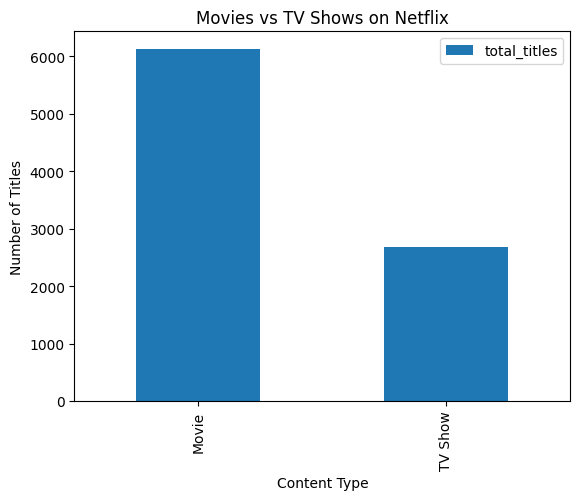

In [64]:
import matplotlib.pyplot as plt
# Run SQL and directly store the result as a DataFrame
df = %sql SELECT type, COUNT(*) AS total_titles FROM netflix_titles GROUP BY type;

# df is ALREADY a pandas DataFrame
df.plot(kind='bar', x='type', y='total_titles')
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()


In [66]:
# Count titles by content type
df = %sql SELECT type, COUNT(*) AS total_titles FROM netflix_titles GROUP BY type;

   sqlite:///:memory:
 * sqlite:///netflix.db


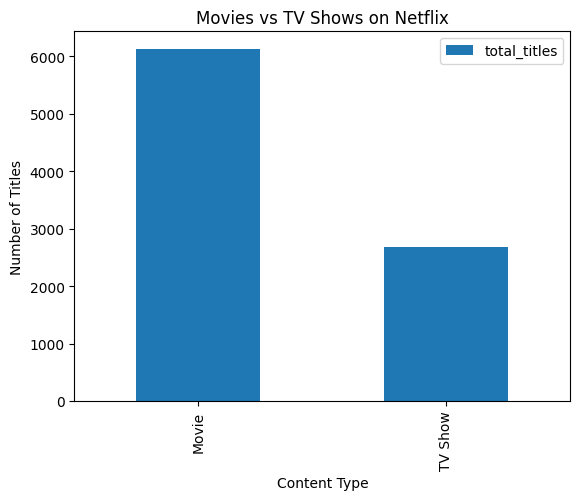

In [67]:
df.plot(kind='bar', x='type', y='total_titles')
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()


In [90]:
# Option 1: Using cell magic (put this at the top of a cell by itself)
%%sql
SELECT SUBSTR(date_added, -4) AS year_added, COUNT(*) AS total_titles 
FROM netflix_titles 
WHERE date_added IS NOT NULL 
GROUP BY year_added 
ORDER BY year_added

# Option 2: Using line magic with the query as a string
result = %sql SELECT SUBSTR(date_added, -4) AS year_added, COUNT(*) AS total_titles FROM netflix_titles WHERE date_added IS NOT NULL GROUP BY year_added ORDER BY year_added

# Option 3: Using sqlalchemy directly if you have a database connection
import pandas as pd
query = """
SELECT SUBSTR(date_added, -4) AS year_added, COUNT(*) AS total_titles 
FROM netflix_titles 
WHERE date_added IS NOT NULL 
GROUP BY year_added 
ORDER BY year_added
"""
df = pd.read_sql(query, connection)

SyntaxError: invalid syntax (1222336093.py, line 3)

In [88]:
# Capture the result of the previous %%sql cell
df = _.DataFrame()


df.plot(x='year_added', y='total_titles')
plt.title("Netflix Titles Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=90)
plt.show()


AttributeError: 'str' object has no attribute 'DataFrame'